# Day 07 — Classification နှင့် Logistic Regression

ဒီနေ့မှာ Regression ကနေ Classification ကို စတင်ပြောင်းလဲလေ့လာပါမယ်။

## 1. Classification ဆိုတာဘာလဲ

Regression က ကိန်းဂဏန်းတန်ဖိုးကို ခန့်မှန်းပါတယ်။

```
Sales = 64.81 သိန်း
House Price = 2,500 သိန်း
```

Classification က အမျိုးအစားကို ခန့်မှန်းပါတယ်။

```
Customer ဝယ်မယ်     = 1
Customer မဝယ်ဘူး    = 0

Email Spam          = 1
Email Not Spam      = 0
```

ဒီနေ့ Project မှာ Customer တစ်ယောက် Product ဝယ်မဝယ်ကို ခန့်မှန်းပါမယ်။

## 2. Libraries Import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## 3. Dataset တည်ဆောက်ခြင်း

Feature သုံးခုသုံးပါမယ်။

- `age` — Customer အသက်
- `monthly_income_lakh` — လစဉ်ဝင်ငွေ (သိန်း)
- `website_visits` — Website ဝင်ကြည့်သည့်အကြိမ်
- `purchased` — ဝယ်ခဲ့လျှင် `1`၊ မဝယ်လျှင် `0`

In [2]:
np.random.seed(42)

rows = 200

age = np.random.randint(18, 61, rows)

monthly_income = np.random.uniform(
    2,
    30,
    rows
).round(2)

website_visits = np.random.randint(
    1,
    21,
    rows
)

score = (
    -7
    + 0.05 * age
    + 0.18 * monthly_income
    + 0.25 * website_visits
)

probability = 1 / (1 + np.exp(-score))

purchased = np.random.binomial(
    1,
    probability
)

df = pd.DataFrame({
    "age": age,
    "monthly_income_lakh": monthly_income,
    "website_visits": website_visits,
    "purchased": purchased
})

df.head()

,age,monthly_income_lakh,website_visits,purchased
0,56,4.26,20,0
1,46,12.35,12,1
2,32,8.78,18,1
3,60,24.49,3,1
4,25,15.17,1,0


## 4. Dataset စစ်ဆေးခြင်း

In [3]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nStatistics:")
display(df.describe())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass counts:")
print(df["purchased"].value_counts())

Dataset shape: (200, 4)

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  200 non-null    int32  
 1   monthly_income_lakh  200 non-null    float64
 2   website_visits       200 non-null    int32  
 3   purchased            200 non-null    int32  
dtypes: float64(1), int32(3)
memory usage: 4.0 KB

Statistics:


,age,monthly_income_lakh,website_visits,purchased
count,200.000000,200.00000,200.000000,200.000000
mean,38.955000,16.11905,10.710000,0.555000
std,12.754858,8.27046,5.735887,0.498213
min,18.000000,2.15000,1.000000,0.000000
25%,27.750000,9.15750,5.750000,0.000000
50%,41.000000,15.61500,11.000000,1.000000
75%,50.000000,23.04750,16.000000,1.000000
max,60.000000,29.90000,20.000000,1.000000



Missing values:
age                    0
monthly_income_lakh    0
website_visits         0
purchased              0
dtype: int64

Class counts:
purchased
1    111
0     89
Name: count, dtype: int64


ဝယ်သူ/မဝယ်သူ ရာခိုင်နှုန်းကို ကြည့်ပါ။

In [4]:
print(
    df["purchased"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

purchased
1    55.5
0    44.5
Name: proportion, dtype: float64


ဒီလို Target အမျိုးအစားတစ်ခုစီမှာ data ဘယ်လောက်ရှိတယ်ဆိုတာကို `class distribution` လို့ခေါ်ပါတယ်။

## 5. Data Visualization

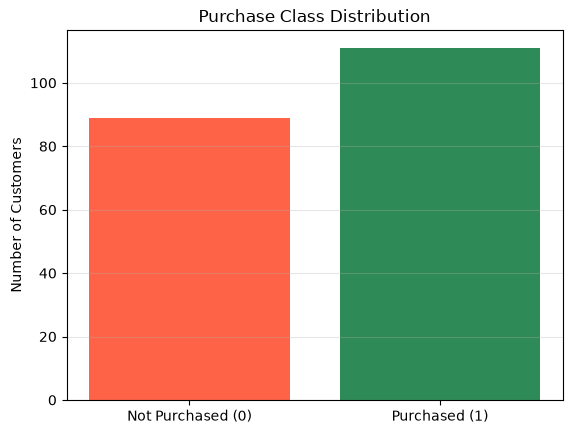

In [5]:
class_counts = (
    df["purchased"]
    .value_counts()
    .sort_index()
)

plt.bar(
    ["Not Purchased (0)", "Purchased (1)"],
    class_counts.values,
    color=["tomato", "seagreen"]
)

plt.ylabel("Number of Customers")
plt.title("Purchase Class Distribution")
plt.grid(axis="y", alpha=0.3)
plt.show()

Income နဲ့ Purchase အခြေအနေကိုကြည့်ပါမယ်။

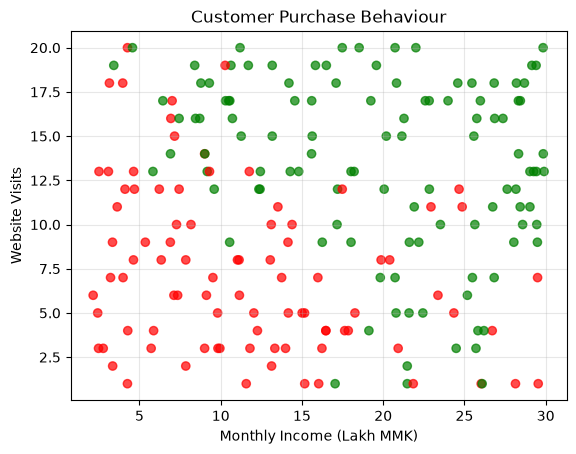

In [6]:
colors = df["purchased"].map({
    0: "red",
    1: "green"
})

plt.scatter(
    df["monthly_income_lakh"],
    df["website_visits"],
    c=colors,
    alpha=0.7
)

plt.xlabel("Monthly Income (Lakh MMK)")
plt.ylabel("Website Visits")
plt.title("Customer Purchase Behaviour")
plt.grid(True, alpha=0.3)
plt.show()

အစိမ်းက ဝယ်သူ၊ အနီက မဝယ်သူဖြစ်ပါတယ်။

## 6. Feature နှင့် Target ခွဲခြင်း

In [7]:
feature_columns = [
    "age",
    "monthly_income_lakh",
    "website_visits"
]

X = df[feature_columns]
y = df["purchased"]

display(X.head())
display(y.head())

,age,monthly_income_lakh,website_visits
0,56,4.26,20
1,46,12.35,12
2,32,8.78,18
3,60,24.49,3
4,25,15.17,1


0    0
1    1
2    1
3    1
4    0
Name: purchased, dtype: int32

## 7. Train/Test Split

Classification မှာ `stratify=y` ထည့်ပေးတာ အရေးကြီးပါတယ်။ Training နဲ့ Testing နှစ်ခုစလုံးမှာ class အချိုး နီးပါးတူနေစေပါတယ်။

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training rows: 160
Testing rows: 40

Training class distribution:
purchased
1    89
0    71
Name: count, dtype: int64

Testing class distribution:
purchased
1    22
0    18
Name: count, dtype: int64


ရလဒ်မှာ—

```
Training rows: 160
Testing rows: 40
```

ဖြစ်ရပါမယ်။

## 8. Logistic Regression Model Training

နာမည်မှာ Regression ပါပေမယ့် `LogisticRegression` ဟာ Classification algorithm ဖြစ်ပါတယ်။

In [9]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)

print("Model training completed.")

Model training completed.


## 9. Prediction ပြုလုပ်ခြင်း

In [10]:
y_pred = model.predict(X_test)

print("Actual values:")
print(y_test.to_numpy())

print("\nPredicted values:")
print(y_pred)

Actual values:
[0 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 0 0 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 0 0
 1 1 0]

Predicted values:
[0 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 0 1 1 1 0 1 1 0 1 0 1 1 0 1 0 0 0
 0 1 0]


Model က `0` သို့မဟုတ် `1` ကို ထုတ်ပေးပါတယ်။

## 10. Accuracy တွက်ခြင်း

In [11]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

Accuracy: 0.8250
Accuracy Percentage: 82.50%


ဥပမာ Accuracy `0.80` ဆိုရင် Testing Customer 100 ယောက်မှာ 80 ယောက်ကို မှန်အောင်ခန့်မှန်းနိုင်တယ်လို့ ဆိုလိုပါတယ်။

ဒါပေမယ့် Accuracy တစ်ခုတည်းနဲ့ Model ကောင်းမကောင်း မဆုံးဖြတ်သင့်ပါဘူး။

## 11. Confusion Matrix

In [12]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[14  4]
 [ 3 19]]


Output structure က—

```
[[TN  FP]
 [FN  TP]]
```

| အမည် | အဓိပ္ပာယ် |
|---|---|
| TN | မဝယ်သူကို မဝယ်ဘူးလို့ မှန်ကန်စွာခန့်မှန်း |
| FP | မဝယ်သူကို ဝယ်မယ်လို့ မှားယွင်းခန့်မှန်း |
| FN | ဝယ်သူကို မဝယ်ဘူးလို့ မှားယွင်းခန့်မှန်း |
| TP | ဝယ်သူကို ဝယ်မယ်လို့ မှန်ကန်စွာခန့်မှန်း |

Graph ဖြင့်ကြည့်ပါ။

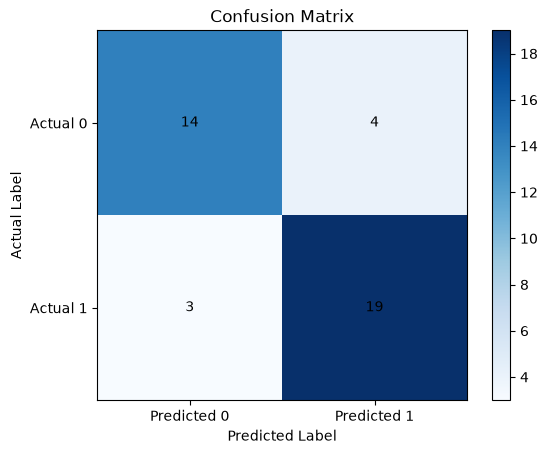

In [13]:
plt.imshow(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(
    [0, 1],
    ["Predicted 0", "Predicted 1"]
)

plt.yticks(
    [0, 1],
    ["Actual 0", "Actual 1"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

## 12. Precision, Recall နှင့် F1-score

In [14]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Not Purchased",
            "Purchased"
        ]
    )
)

               precision    recall  f1-score   support

Not Purchased       0.82      0.78      0.80        18
    Purchased       0.83      0.86      0.84        22

     accuracy                           0.82        40
    macro avg       0.82      0.82      0.82        40
 weighted avg       0.82      0.82      0.82        40



အဓိပ္ပာယ်က—

- `Precision` — ဝယ်မယ်လို့ ခန့်မှန်းထသူတွေထဲမှာ တကယ်ဝယ်သူ ဘယ်လောက်ရှိသလဲ။
- `Recall` — တကယ်ဝယ်သူတွေထဲက ဘယ်လောက်ကို Model က ရှာတွေ့သလဲ။
- `F1-score` — Precision နဲ့ Recall ကို မျှတစွာပေါင်းစပ်ထားတဲ့ score ဖြစ်ပါတယ်။
- `Support` — Class တစ်ခုစီမှာရှိတဲ့ testing rows အရေအတွက်ဖြစ်ပါတယ်။

## 13. Probability ခန့်မှန်းခြင်း

In [15]:
probabilities = model.predict_proba(
    X_test
)

probability_results = X_test.copy()

probability_results["actual"] = y_test
probability_results["predicted"] = y_pred

probability_results["purchase_probability"] = (
    probabilities[:, 1]
).round(4)

probability_results.head(10)

,age,monthly_income_lakh,website_visits,actual,predicted,purchase_probability
172,59,3.34,9,0,0,0.0523
22,38,25.46,18,1,1,0.9968
141,46,29.03,13,1,1,0.9946
71,57,15.63,15,1,1,0.9311
5,38,29.54,1,0,1,0.6846
127,32,14.28,13,1,1,0.6488
87,25,22.94,11,0,1,0.8866
54,21,15.60,17,1,1,0.8830
171,50,22.44,5,1,1,0.6599
183,54,23.37,6,0,1,0.8060


`purchase_probability = 0.78` ဆိုရင် Model အရ ဝယ်နိုင်ချေ `78%` လို့ အဓိပ္ပာယ်ရပါတယ်။

Default threshold က `0.50` ဖြစ်ပါတယ်။

```
Probability >= 0.50 → Purchased (1)
Probability < 0.50  → Not Purchased (0)
```

## 14. Customer အသစ်ခန့်မှန်းခြင်း

In [16]:
new_customer = pd.DataFrame({
    "age": [35],
    "monthly_income_lakh": [18],
    "website_visits": [12]
})

prediction = model.predict(
    new_customer
)

prediction_probability = model.predict_proba(
    new_customer
)[0, 1]

print("Predicted class:", prediction[0])

print(
    f"Purchase probability: "
    f"{prediction_probability * 100:.2f}%"
)

if prediction[0] == 1:
    print("Result: Customer may purchase.")
else:
    print("Result: Customer may not purchase.")

Predicted class: 1
Purchase probability: 80.20%
Result: Customer may purchase.


## 15. Customer အများအပြားခန့်မှန်းခြင်း

In [17]:
new_customers = pd.DataFrame({
    "age": [22, 30, 40, 55],
    "monthly_income_lakh": [4, 10, 20, 28],
    "website_visits": [2, 7, 13, 19]
})

new_customers["prediction"] = model.predict(
    new_customers
)

new_customers["purchase_probability"] = (
    model.predict_proba(new_customers)[:, 1]
    * 100
).round(2)

new_customers

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- prediction


## Day 07 လေ့ကျင့်ခန်း

Model ကို အောက်ပါ Customer နှစ်ယောက်အတွက် စမ်းသပ်ပါ။

In [ ]:
exercise_customers = pd.DataFrame({
    "age": [28, 48],
    "monthly_income_lakh": [8, 24],
    "website_visits": [5, 16]
})

predictions = model.predict(exercise_customers)
probabilities = model.predict_proba(exercise_customers)[:, 1] * 100

exercise_customers["prediction"] = predictions
exercise_customers["probability_percent"] = probabilities.round(2)

exercise_customers